# 05 — Interpretación del modelo e insights de negocio

## Modelo predictivo para anticipar incumplimientos de SLA en HR Operations  
## (Predictive Model to Anticipate SLA Breaches in HR Operations)

En el notebook anterior se optimizó un modelo Random Forest mediante GridSearchCV.

El modelo optimizado fue seleccionado como candidato final porque mejoró significativamente el recall de la clase `1`, es decir, la capacidad para detectar tickets que realmente incumplen SLA.

El objetivo de este notebook es interpretar el modelo y traducir sus resultados en conclusiones de negocio.

## Objetivo del notebook

Este notebook busca responder tres preguntas:

1. ¿Qué variables influyen más en la predicción de incumplimiento SLA?
2. ¿Qué patrones operativos parecen estar asociados al riesgo de incumplimiento?
3. ¿Cómo puede usar HR Operations este modelo para priorizar tickets y reducir retrasos?

El foco no está solo en el rendimiento técnico del modelo, sino en su utilidad para la toma de decisiones.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
# Cargamos el dataset final:
ruta_datos = "../data/processed/tickets_hr_sla_model_ready.csv"

df = pd.read_csv(ruta_datos)

df.head()

,Customer Age,Product Purchased,Ticket Type,Ticket Subject,Ticket Priority,Ticket Channel,incumplio_sla
0,48,Dell XPS,Technical issue,Network problem,Low,Social media,0
1,27,Microsoft Office,Billing inquiry,Account access,Low,Social media,0
2,67,Autodesk AutoCAD,Billing inquiry,Data loss,Low,Email,0
3,48,Nintendo Switch,Cancellation request,Data loss,High,Phone,0
4,51,Microsoft Xbox Controller,Product inquiry,Software bug,High,Chat,1


In [6]:
df.shape

(2769, 7)

In [7]:
df.columns

Index(['Customer Age', 'Product Purchased', 'Ticket Type', 'Ticket Subject',
       'Ticket Priority', 'Ticket Channel', 'incumplio_sla'],
      dtype='object')

## Preparación de datos para interpretación

Se utilizará el mismo dataset final de modelado y la misma división train/test utilizada en los notebooks anteriores.

Esto permite mantener consistencia entre la fase de entrenamiento, optimización e interpretación.

In [8]:
X = df.drop(columns="incumplio_sla")
y = df["incumplio_sla"]

X.head()

,Customer Age,Product Purchased,Ticket Type,Ticket Subject,Ticket Priority,Ticket Channel
0,48,Dell XPS,Technical issue,Network problem,Low,Social media
1,27,Microsoft Office,Billing inquiry,Account access,Low,Social media
2,67,Autodesk AutoCAD,Billing inquiry,Data loss,Low,Email
3,48,Nintendo Switch,Cancellation request,Data loss,High,Phone
4,51,Microsoft Xbox Controller,Product inquiry,Software bug,High,Chat


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2215, 6)
X_test: (554, 6)
y_train: (2215,)
y_test: (554,)


In [10]:
columnas_numericas = ["Customer Age"]

columnas_categoricas = [
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Channel"
]

preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), columnas_numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

## Reconstrucción del modelo final

Se reconstruye el modelo Random Forest optimizado con los mejores hiperparámetros encontrados mediante GridSearchCV.

Los mejores hiperparámetros fueron:

- `class_weight`: balanced
- `max_depth`: 5
- `min_samples_leaf`: 2
- `min_samples_split`: 5
- `n_estimators`: 200

Esta configuración fue seleccionada porque mejoró significativamente el recall de la clase `1`.

In [11]:
modelo_final = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=2,
            min_samples_split=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

modelo_final.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Customer Age']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product Purchased',
                                                   'Ticket Type',
                                                   'Ticket Subject',
                                                   'Ticket Priority',
                                                   'Ticket Channel'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [12]:
y_pred_final = modelo_final.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print("Modelo final: Random Forest optimizado")
print("Accuracy:", round(accuracy_final, 4))
print("Precision clase 1:", round(precision_final, 4))
print("Recall clase 1:", round(recall_final, 4))
print("F1-score clase 1:", round(f1_final, 4))

Modelo final: Random Forest optimizado
Accuracy: 0.7292
Precision clase 1: 0.6115
Recall clase 1: 0.8019
F1-score clase 1: 0.6939


In [13]:
matriz_final = confusion_matrix(y_test, y_pred_final)

matriz_final

array([[234, 108],
       [ 42, 170]])

## Interpretación del rendimiento final

El modelo final Random Forest optimizado alcanzó un recall de clase `1` cercano al 80%.

Esto significa que el modelo detecta aproximadamente 8 de cada 10 tickets que realmente incumplen SLA.

Desde el punto de vista de negocio, este resultado es relevante porque reduce la cantidad de tickets críticos no detectados.

Aunque el modelo genera algunas falsas alarmas, este trade-off es aceptable en un contexto operativo donde es preferible revisar tickets adicionales antes que dejar sin detectar casos con alto riesgo de incumplimiento.

## Importancia de variables

Random Forest permite estimar la importancia relativa de las variables utilizadas en la predicción.

Como el modelo utiliza One-Hot Encoding para variables categóricas, primero se recuperan los nombres de las variables transformadas y luego se extraen las importancias del modelo.

In [14]:
preprocesador_entrenado = modelo_final.named_steps["preprocesamiento"]
modelo_entrenado = modelo_final.named_steps["modelo"]

nombres_numericas = columnas_numericas

nombres_categoricas = (
    preprocesador_entrenado
    .named_transformers_["categoricas"]
    .get_feature_names_out(columnas_categoricas)
)

nombres_variables = list(nombres_numericas) + list(nombres_categoricas)

importancias = modelo_entrenado.feature_importances_

df_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

df_importancias.head(20)

,variable,importancia
66,Ticket Priority_Low,0.329830
64,Ticket Priority_Critical,0.309046
67,Ticket Priority_Medium,0.071599
65,Ticket Priority_High,0.062960
0,Customer Age,0.028330
27,Product Purchased_Microsoft Surface,0.009140
19,Product Purchased_Google Pixel,0.007267
70,Ticket Channel_Phone,0.006612
46,Ticket Type_Refund request,0.006023
71,Ticket Channel_Social media,0.005784


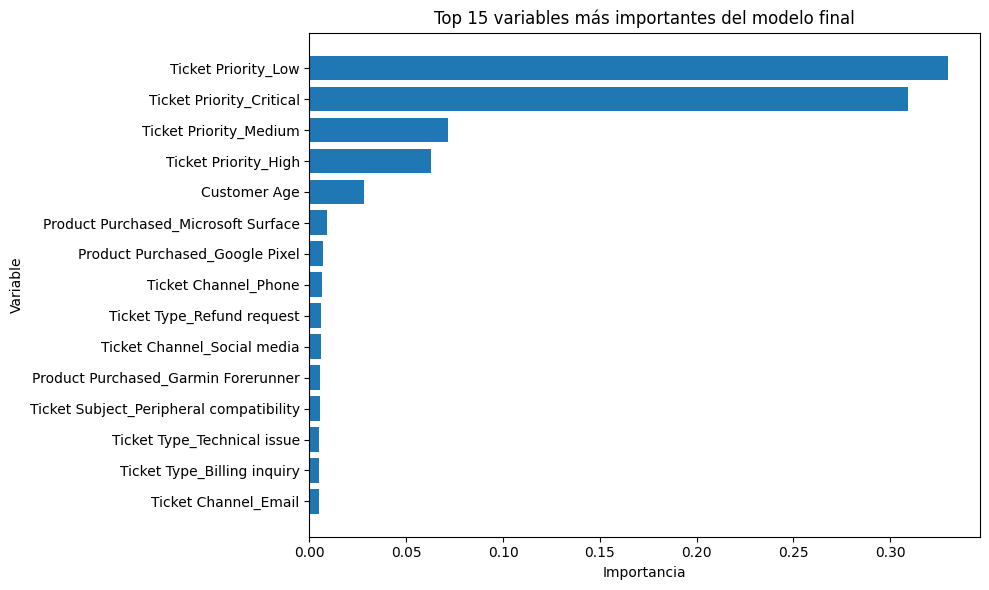

In [15]:
top_15_importancias = df_importancias.head(15).sort_values(
    by="importancia",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_15_importancias["variable"],
    top_15_importancias["importancia"]
)

plt.title("Top 15 variables más importantes del modelo final")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Lectura inicial de la importancia de variables

La importancia de variables permite identificar qué características del ticket tienen mayor peso en la predicción de incumplimiento SLA.

Estas variables no deben interpretarse como causas directas, sino como señales predictivas que el modelo utiliza para diferenciar tickets con mayor o menor riesgo.

En un contexto operativo, esta información puede ayudar a detectar qué tipos de tickets, prioridades, canales o categorías deberían recibir mayor atención preventiva.

In [16]:
# Ahora agrupamos importancias por familia de variable para facilitar su explicación en terminos de negocio:
def agrupar_variable(variable):
    if variable == "Customer Age":
        return "Customer Age"
    if variable.startswith("Product Purchased"):
        return "Product Purchased"
    if variable.startswith("Ticket Type"):
        return "Ticket Type"
    if variable.startswith("Ticket Subject"):
        return "Ticket Subject"
    if variable.startswith("Ticket Priority"):
        return "Ticket Priority"
    if variable.startswith("Ticket Channel"):
        return "Ticket Channel"
    return "Other"

df_importancias["grupo_variable"] = df_importancias["variable"].apply(agrupar_variable)

importancia_por_grupo = (
    df_importancias
    .groupby("grupo_variable", as_index=False)["importancia"]
    .sum()
    .sort_values(by="importancia", ascending=False)
)

importancia_por_grupo

,grupo_variable,importancia
3,Ticket Priority,0.773435
1,Product Purchased,0.103511
4,Ticket Subject,0.049076
0,Customer Age,0.028330
5,Ticket Type,0.023731
2,Ticket Channel,0.021917


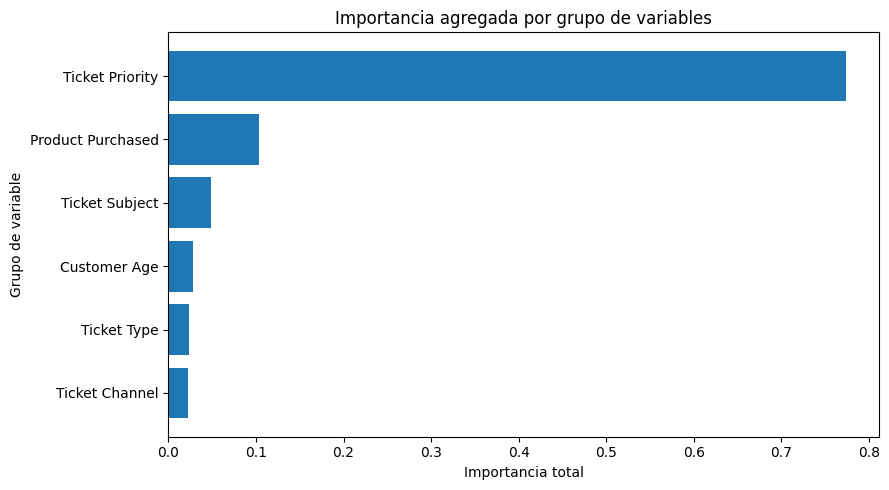

In [17]:
importancia_por_grupo_ordenado = importancia_por_grupo.sort_values(
    by="importancia",
    ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    importancia_por_grupo_ordenado["grupo_variable"],
    importancia_por_grupo_ordenado["importancia"]
)

plt.title("Importancia agregada por grupo de variables")
plt.xlabel("Importancia total")
plt.ylabel("Grupo de variable")
plt.tight_layout()
plt.show()

## Interpretación por grupos de variables

La importancia agregada permite interpretar el modelo a un nivel más ejecutivo.

En lugar de analizar cada categoría individual, se agrupan las variables por dimensión operativa:

- Edad del cliente.
- Producto o servicio asociado.
- Tipo de ticket.
- Asunto del ticket.
- Prioridad.
- Canal de entrada.

Esta lectura facilita traducir el resultado del modelo a decisiones operativas.

## Interpretación de la importancia de variables

La importancia agregada por grupo muestra que `Ticket Priority` es la variable más relevante del modelo, con una importancia aproximada de 0,7734.

Esto significa que la prioridad del ticket concentra gran parte de la capacidad predictiva del modelo.

Este resultado es coherente con la lógica del proyecto, ya que la variable objetivo `incumplio_sla` fue construida comparando el tiempo de resolución contra un SLA esperado definido por prioridad.

Después de la prioridad, las variables con mayor peso son `Product Purchased`, `Ticket Subject`, `Customer Age`, `Ticket Type` y `Ticket Channel`, aunque con una importancia mucho menor.

Desde una perspectiva de negocio, esto sugiere que la priorización operativa es el principal factor asociado al riesgo de incumplimiento SLA en este modelo.

## Consideración metodológica

La alta importancia de `Ticket Priority` debe interpretarse con cautela.

En este proyecto, el SLA esperado fue definido mediante una regla de negocio basada en la prioridad del ticket. Por esta razón, es esperable que la prioridad aparezca como la variable más influyente en el modelo.

Esto no invalida el modelo, ya que en entornos operativos reales los SLA suelen depender precisamente de la prioridad del caso. Sin embargo, sí implica que el modelo depende en gran medida de una variable directamente relacionada con la construcción de la variable objetivo.

En una versión futura del proyecto, sería recomendable incorporar más variables operativas reales, como carga de trabajo del equipo, número de reasignaciones, complejidad del caso, país, región, agente asignado o número de interacciones, para reducir la dependencia del modelo respecto a la prioridad.

## Insights de negocio

A partir del modelo final, se identifican los siguientes insights:

1. El modelo optimizado detecta aproximadamente el 80% de los tickets que realmente incumplen SLA.
2. La prioridad del ticket es la señal predictiva más fuerte del modelo.
3. Los tickets con prioridades más exigentes requieren seguimiento preventivo más temprano.
4. El modelo reduce los falsos negativos frente al Random Forest base, lo que significa que deja escapar menos casos críticos.
5. El modelo genera más falsas alarmas, pero este trade-off es aceptable si el objetivo principal es prevenir incumplimientos.
6. Variables como producto asociado, asunto, tipo de ticket y canal aportan señales secundarias útiles.
7. El modelo puede ayudar a HR Operations a pasar de una gestión reactiva a una gestión preventiva basada en riesgo.


## Insight principal

El modelo muestra que la prioridad del ticket es el principal indicador temprano de riesgo de incumplimiento SLA.

Esto sugiere que HR Operations debería reforzar los mecanismos de seguimiento preventivo para tickets de mayor prioridad, especialmente aquellos clasificados como críticos o de alta urgencia.

Sin embargo, el modelo también muestra que existen señales secundarias asociadas al producto/servicio, asunto del ticket, tipo de ticket y canal de entrada. Estas variables pueden ayudar a construir una estrategia de priorización más completa que no dependa únicamente de la prioridad asignada.

## Recomendación operativa

Se recomienda implementar un sistema de scoring de riesgo que combine la prioridad del ticket con otras variables operativas disponibles al inicio del caso.

Este score permitiría clasificar los tickets en niveles de riesgo:

- Riesgo alto: revisar de forma prioritaria.
- Riesgo medio: monitorizar durante el ciclo de resolución.
- Riesgo bajo: seguir flujo operativo estándar.

El objetivo no sería reemplazar la gestión humana, sino ayudar al equipo de HR Operations a identificar antes los casos que tienen mayor probabilidad de incumplir su SLA.

## Recomendaciones para HR Operations

A partir del modelo final, se recomienda:

1. Implementar un score de riesgo de incumplimiento SLA en la bandeja de tickets.
2. Priorizar tickets clasificados como riesgo alto.
3. Crear alertas tempranas para casos críticos.
4. Monitorizar tickets de alta prioridad antes de que se acerquen al límite del SLA.
5. Revisar la capacidad operativa por tipo de ticket, canal y prioridad.
6. Usar el modelo como herramienta de apoyo, no como sistema automático de decisión.
7. Reentrenar el modelo periódicamente con datos reales actualizados.

## Limitaciones del modelo

El modelo presenta varias limitaciones:

1. El dataset original no pertenece directamente a HR Operations, sino a tickets de soporte adaptados al contexto del proyecto.
2. La variable `incumplio_sla` fue construida mediante una regla de negocio simulada basada en prioridad.
3. La duración del ticket requirió una corrección temporal debido a inconsistencias en las fechas.
4. La variable `Ticket Priority` tiene mucha influencia porque también fue utilizada para definir el SLA esperado.
5. No se dispone de variables operativas reales como carga de trabajo, país, región, agente asignado, reasignaciones o número de interacciones.
6. La importancia de variables no debe interpretarse como causalidad.

## Próximos pasos

Para mejorar el proyecto en una versión futura, se podrían incorporar:

1. Datos reales de HR Operations.
2. Variables de carga operativa por equipo.
3. Número de reasignaciones del caso.
4. Número de comentarios o interacciones.
5. País, región o unidad de negocio.
6. Seniority del agente asignado.
7. Complejidad estimada del caso.
8. Técnicas de NLP sobre la descripción del ticket.
9. Dashboard operativo con score de riesgo.
10. Monitorización continua del rendimiento del modelo.

## Conclusión final

El proyecto demuestra que es posible construir un modelo predictivo para anticipar incumplimientos de SLA en un entorno operativo basado en tickets.

El modelo final seleccionado fue Random Forest optimizado, ya que ofreció una mejora significativa en la detección de tickets que incumplen SLA.

El recall de la clase `1` alcanzó aproximadamente el 80%, lo que significa que el modelo es capaz de detectar la mayoría de los casos críticos.

Desde una perspectiva de negocio, el valor del modelo está en pasar de una gestión reactiva de tickets a una gestión preventiva, donde los equipos de HR Operations pueden priorizar casos de riesgo antes de que se produzca el incumplimiento.

El modelo debe entenderse como una herramienta de apoyo a la toma de decisiones operativas, no como un sistema automático de decisión.

## Guardado del modelo final

Después de entrenar e interpretar el modelo final, se guarda el pipeline completo para poder reutilizarlo posteriormente.

El objeto guardado incluye:

- Preprocesamiento de variables numéricas y categóricas.
- Codificación One-Hot Encoding.
- Escalado de variables numéricas.
- Modelo Random Forest optimizado.

Guardar el pipeline completo permite usar el modelo directamente en una futura aplicación de Streamlit o en un entorno productivo simulado.

In [20]:
# Guardar el modelo final entrenado para su uso en producción:
import joblib
import os

os.makedirs("../models", exist_ok=True)

ruta_modelo = "../models/modelo_random_forest_sla.pkl"

joblib.dump(modelo_final, ruta_modelo)

print(f"Modelo final guardado correctamente en: {ruta_modelo}")

Modelo final guardado correctamente en: ../models/modelo_random_forest_sla.pkl


In [21]:
# Verificar carga del modelo guardado:
modelo_cargado = joblib.load("../models/modelo_random_forest_sla.pkl")

modelo_cargado

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Customer Age']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product Purchased',
                                                   'Ticket Type',
                                                   'Ticket Subject',
                                                   'Ticket Priority',
                                                   'Ticket Channel'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [22]:
# Probar una predicción rápida con el modelo cargado:
ejemplo_ticket = X_test.iloc[[0]]

prediccion = modelo_cargado.predict(ejemplo_ticket)
probabilidad = modelo_cargado.predict_proba(ejemplo_ticket)

print("Predicción:", prediccion[0])
print("Probabilidad de cumplir SLA:", round(probabilidad[0][0], 4))
print("Probabilidad de incumplir SLA:", round(probabilidad[0][1], 4))

Predicción: 1
Probabilidad de cumplir SLA: 0.4803
Probabilidad de incumplir SLA: 0.5197
